# 01 — EDA
Understand the data before modelling. Every finding here informs decisions in later notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROC = Path('../Data/Processed')
OUT  = Path('../Outputs')
OUT.mkdir(exist_ok=True)

master = pd.read_parquet(PROC / 'master.parquet')

## 1. Default rate by key segments

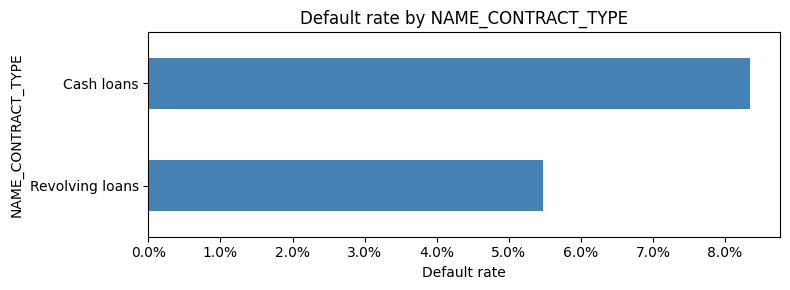

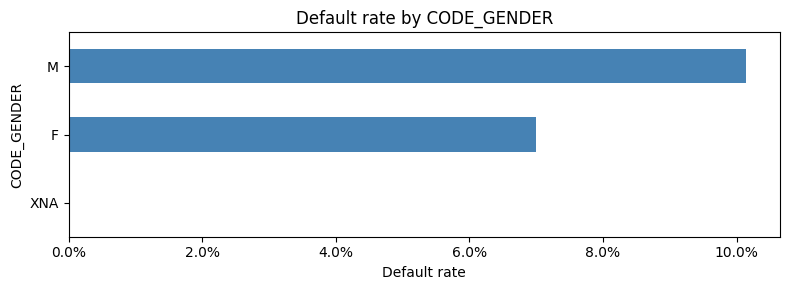

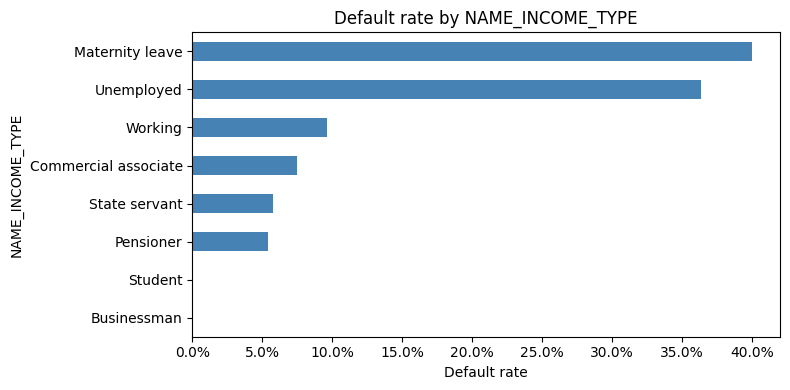

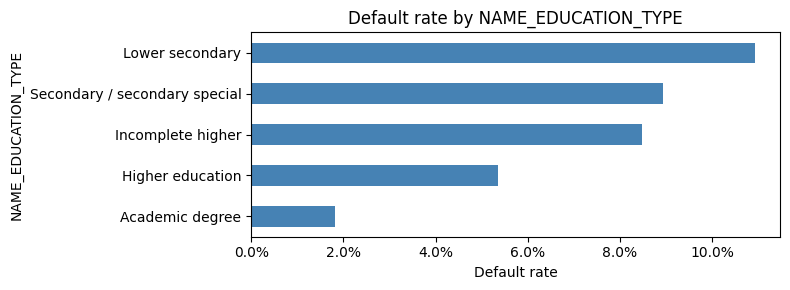

In [2]:
segment_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']

for col in segment_cols:
    # default rate = mean of TARGET per category
    dr = master.groupby(col)['TARGET'].mean().sort_values()

    fig, ax = plt.subplots(figsize=(8, max(3, len(dr) * 0.5)))
    dr.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Default rate')
    ax.set_title(f'Default rate by {col}')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
    plt.tight_layout()
    plt.savefig(OUT / f'dr_{col}.png', dpi=100)
    plt.show()

## 2. Distributions split by target

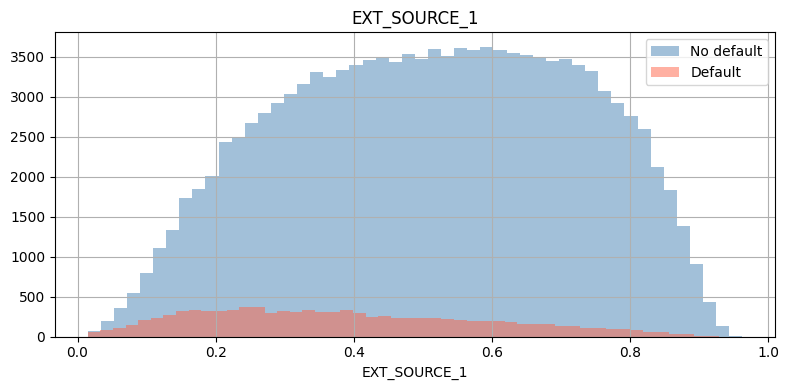

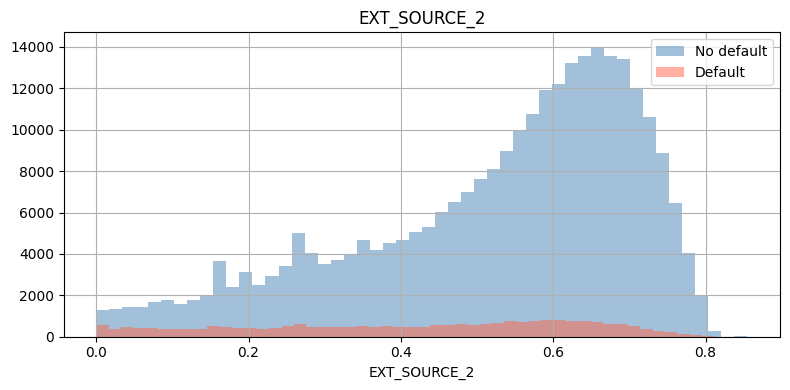

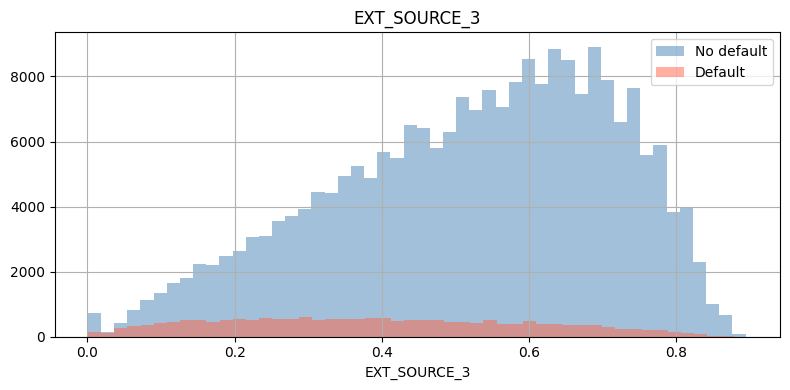

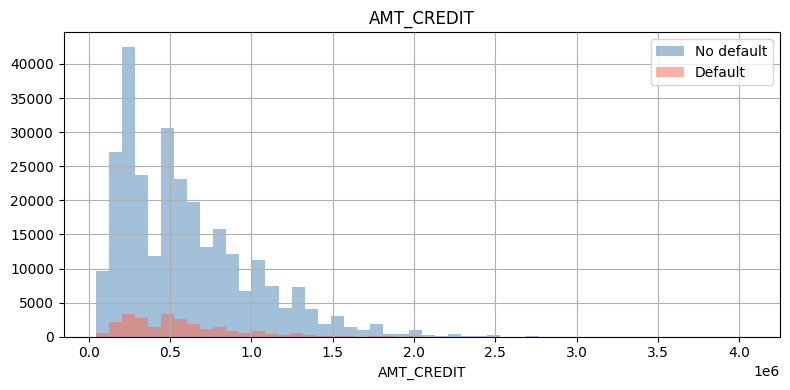

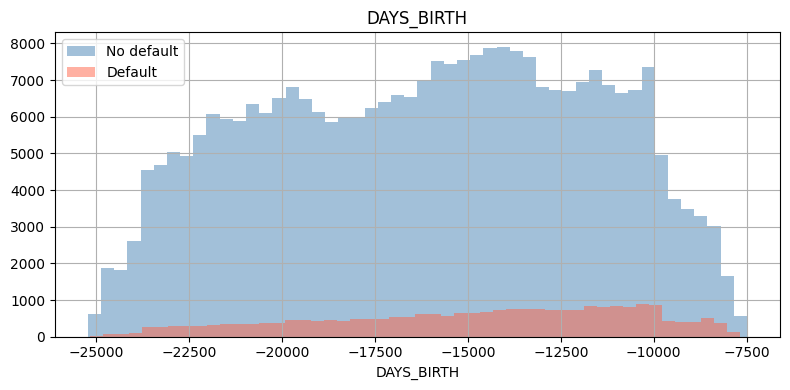

In [3]:
dist_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_CREDIT', 'DAYS_BIRTH']

for col in dist_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    # overlay defaulters vs non-defaulters — NaNs dropped per column
    master[master['TARGET'] == 0][col].dropna().hist(bins=50, alpha=0.5, label='No default', ax=ax, color='steelblue')
    master[master['TARGET'] == 1][col].dropna().hist(bins=50, alpha=0.5, label='Default',    ax=ax, color='tomato')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT / f'dist_{col}.png', dpi=100)
    plt.show()

## 3. Missing value summary

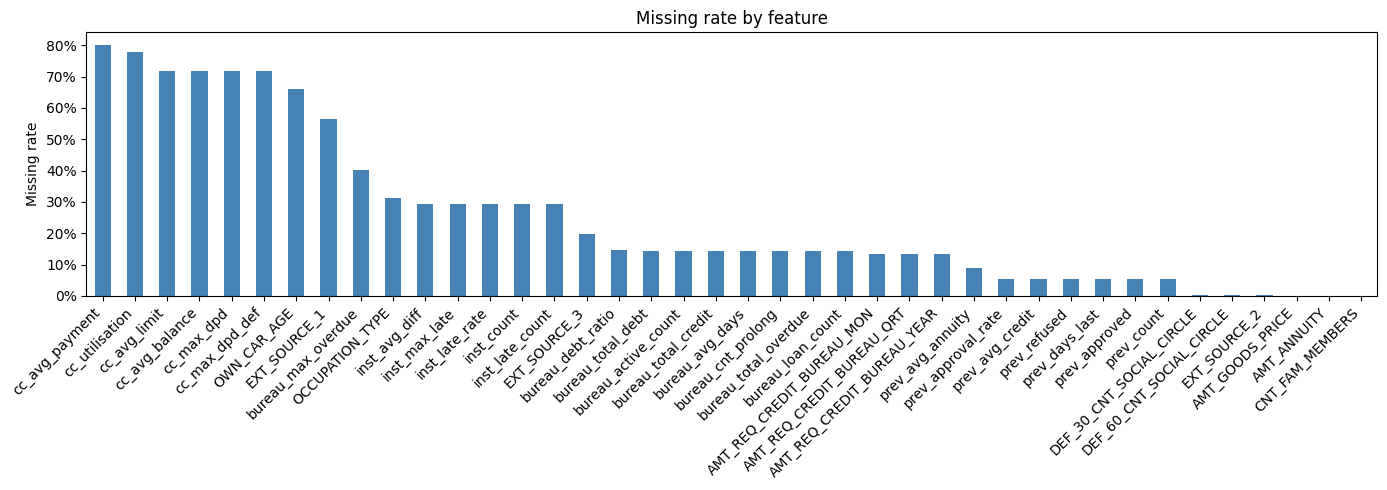

Total features with missing values: 40
cc_avg_payment                0.801
cc_utilisation                0.779
cc_avg_limit                  0.717
cc_avg_balance                0.717
cc_max_dpd                    0.717
cc_max_dpd_def                0.717
OWN_CAR_AGE                   0.660
EXT_SOURCE_1                  0.564
bureau_max_overdue            0.402
OCCUPATION_TYPE               0.313
inst_avg_diff                 0.293
inst_max_late                 0.293
inst_late_rate                0.293
inst_count                    0.293
inst_late_count               0.293
EXT_SOURCE_3                  0.198
bureau_debt_ratio             0.147
bureau_total_debt             0.143
bureau_active_count           0.143
bureau_total_credit           0.143
bureau_avg_days               0.143
bureau_cnt_prolong            0.143
bureau_total_overdue          0.143
bureau_loan_count             0.143
AMT_REQ_CREDIT_BUREAU_MON     0.135
AMT_REQ_CREDIT_BUREAU_QRT     0.135
AMT_REQ_CREDIT_BUREAU_YEA

In [4]:
# keep only columns that have at least one missing value
missing = master.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(14, 5))
missing.plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Missing rate')
ax.set_title('Missing rate by feature')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT / 'missing_rates.png', dpi=100)
plt.show()

print(f"Total features with missing values: {len(missing)}")
print(missing.round(3).to_string())